# Tutorial: architectures of the echo state network

One class, `EchoStateNetwork`, builds several architectures through the keywords
of its constructor. The keywords set which components the reservoir reads, what
the readout reads, how the state splits into patches, and which hyperparameters
the Bayesian optimization selects. In this tutorial, we draw the architecture
that a set of keywords builds, so that different architectures can be compared
side by side. First, we explain how to read a drawing. Second, we draw a gallery
of architectures. Third, we list the combinations of keywords that the class
rejects. Fourth, an explorer redraws the architecture as the keywords change.

The drawing is computed from the network itself (`patch_sites`, `N_r` and the
shapes of the matrices), so it shows the network that the keywords build. The
drawing code is in `plots_06.py`, next to this notebook. The explorer of the last
section requires `ipywidgets` (`pip install ipywidgets`) and a running kernel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from echostatenetwork import EchoStateNetwork
from plots_06 import draw_esn

plt.rcParams.update({'font.family': 'STIXGeneral', 'mathtext.fontset': 'stix', 'font.size': 11})

## How to read a drawing

We start from a single reservoir that reads the whole state. From left to right:

- the input strip, $\tilde{\bm{u}}_n$, is the normalized input at step $n$, with
  one cell per component of the state (blue);
- the brace marks the components that the reservoir reads through the input
  matrix, $\bm{W}_\mathrm{in}$;
- the reservoir, $\bm{r}$, is drawn as a recurrent network of neurons (grey),
  whose connections are the reservoir matrix, $\bm{W}$;
- the readout matrix, $\bm{W}_\mathrm{out}$, maps the reservoir state to the
  forecast, $\hat{\bm{u}}_{n+1}$, which is the output strip (teal).

In closed loop (bottom arrow), the forecast is the input of the next step. Under
the drawing, we print the update of the reservoir and the readout, the shapes of
the matrices, the number of rows of the reservoir state, and the hyperparameters:
the hyperparameters that the Bayesian optimization searches, with their ranges,
and the fixed hyperparameters, with their values. The symbols are those of the
[training page](https://andreanovoa.github.io/EchoStateNetwork/training/).

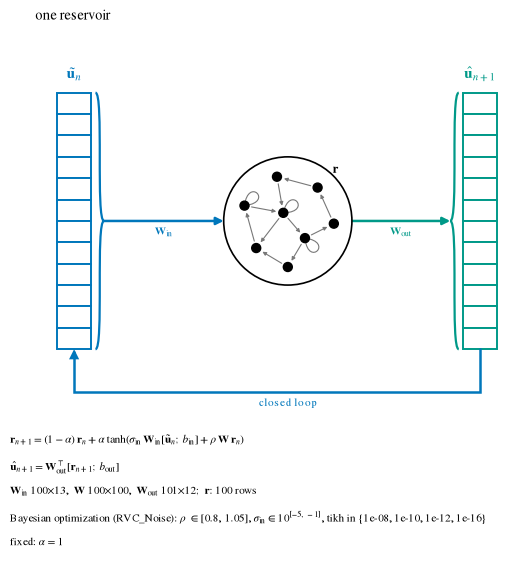

In [2]:
N_DIM = 12                    # components (sites) of the state
y = np.zeros((N_DIM, 1))      # only the shape of the data matters: nothing is trained here

draw_esn(EchoStateNetwork(y, N_units=100), title='one reservoir');

## A gallery of architectures

Each panel changes one or two keywords with respect to the single reservoir above;
the panel titles list them.

- (a) Partial observation (`observed_idx`). The reservoir reads only the observed
  components (solid cells). The readout still forecasts every component, and the
  closed loop feeds back the observed components.
- (b) Leaky integrator (`leak_rate` below one). The reservoir keeps a fraction
  $1-\alpha$ of its previous state (loop above the reservoir). With `'leak_rate'` in
  `hyperparameters_to_optimize`, the Bayesian optimization selects $\alpha$, as in
  tutorial 03.
- (c) Parametric input (`input_parameters`) with an input skip
  (`readout_input=True`). The parameters, $\tilde{\bm{p}}$ (orange), join the
  input of the reservoir at a junction (white diamond), as in tutorial 02. The
  input skip leaves the input arrow downwards and enters the readout arrow from
  below, so that the readout reads the input directly.
- (d) Parameters through the readout only (`param_in_reservoir=False` and
  `readout_input='params'`). The parameters bypass the reservoir and enter the
  readout arrow from above.
- (e) Parallel layout with shared matrices (`patch_size` and `halo`). One reservoir
  per patch reads its patch and `halo` sites on either side, and forecasts its
  patch. Each cell of the input strip is hatched with the pattern of every
  reservoir that reads it, and each cell of the output strip with the pattern of
  the reservoir that forecasts it. On a ring, the windows of the first and last
  patches wrap around (dashed copies of the sites).
- (f) Independent patches (`shared=False`) on a non-periodic domain
  (`periodic=False`). Every patch has its own matrices and hyperparameters
  (coloured networks, superscript $(p)$). The windows of the patches at the
  boundaries read zeros outside the domain (grey cells), as explained on the
  [parallel page](https://andreanovoa.github.io/EchoStateNetwork/parallel/).

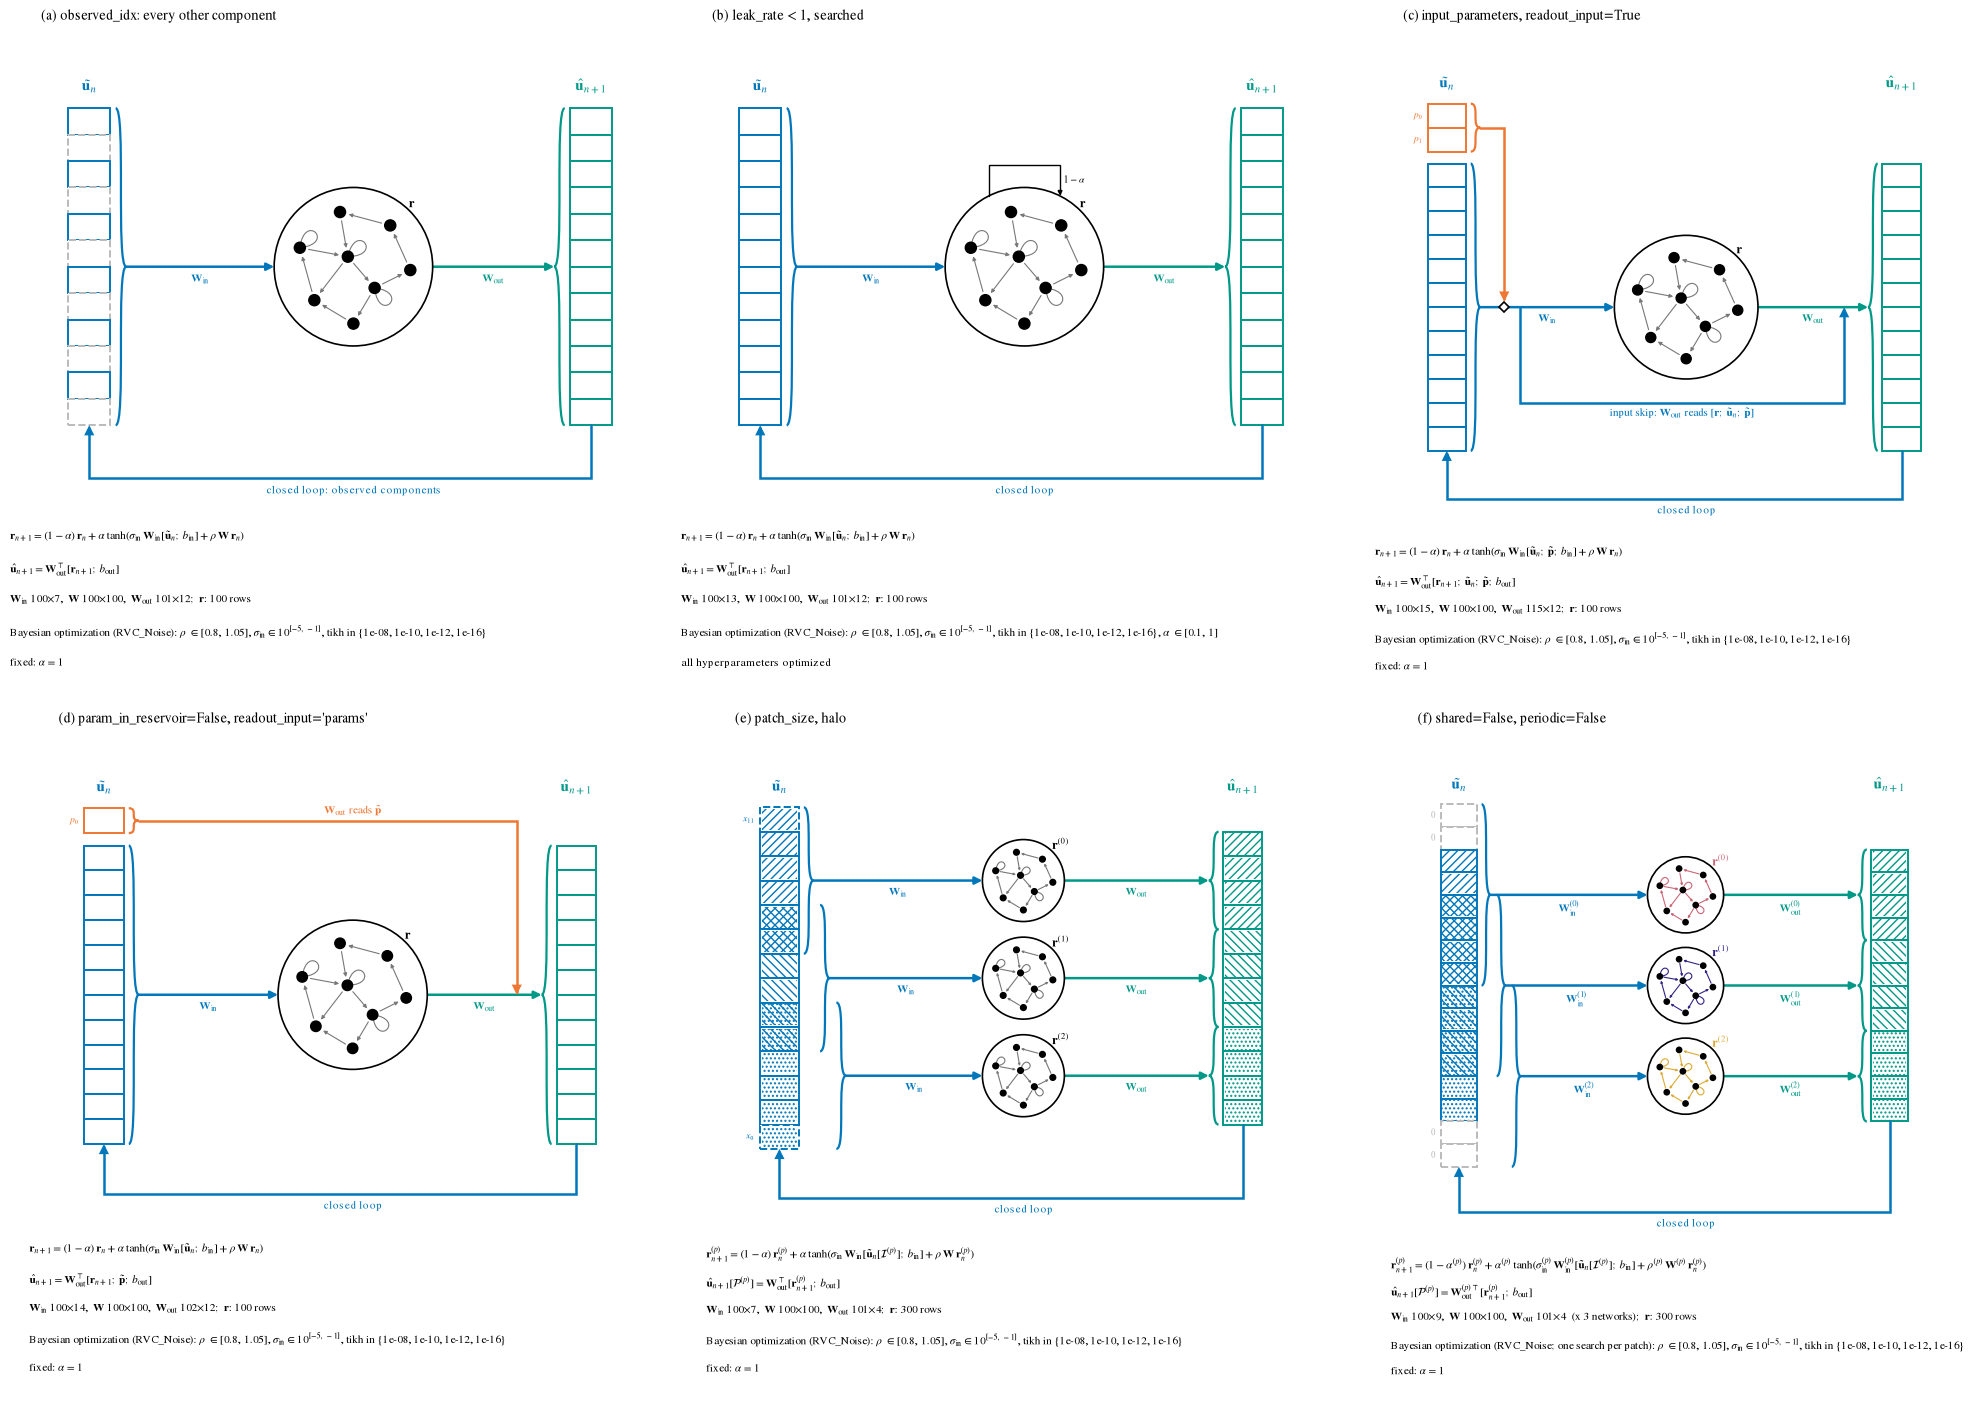

In [3]:
gallery = {
    '(a) observed_idx: every other component': dict(observed_idx=np.arange(0, N_DIM, 2)),
    "(b) leak_rate < 1, searched": dict(leak_rate=0.3,
                                        hyperparameters_to_optimize=['rho', 'sigma_in', 'tikh', 'leak_rate']),
    '(c) input_parameters, readout_input=True': dict(input_parameters=np.zeros((2, 1)), readout_input=True),
    "(d) param_in_reservoir=False, readout_input='params'": dict(input_parameters=np.zeros((1, 1)),
                                                                 param_in_reservoir=False,
                                                                 readout_input='params'),
    '(e) patch_size, halo': dict(patch_size=4, halo=1),
    '(f) shared=False, periodic=False': dict(patch_size=4, halo=2, shared=False, periodic=False),
}
fig, axs = plt.subplots(2, 3, figsize=(20, 14), layout='constrained')
for ax, (title, kw) in zip(axs.flat, gallery.items()):
    draw_esn(EchoStateNetwork(y, N_units=100, **kw), ax, title=title)

Compare the shapes printed under panels (e) and (f) with those of the single
reservoir. With the parallel layout, $\bm{W}_\mathrm{in}$ reads one window and
$\bm{W}_\mathrm{out}$ forecasts one patch. The reservoir state stacks the
reservoirs of all the patches, so it has more rows than one reservoir.

## Combinations that the class rejects

The parallel layout requires every site of the state as input and output, so it
cannot be combined with partial observation, parametric inputs or an input skip,
and `patch_size` must divide the number of sites. For these combinations, the
constructor raises a `ValueError` that explains the reason. The explorer below
prints this message instead of a drawing.

In [4]:
rejected = [dict(patch_size=5),
            dict(patch_size=4, observed_idx=np.arange(0, N_DIM, 2)),
            dict(patch_size=4, readout_input=True),
            dict(shared=False)]
for kw in rejected:
    try:
        EchoStateNetwork(y, **kw)
    except ValueError as err:
        print(f'{sorted(kw)}: {err}')

['patch_size']: patch_size=5 must be a positive integer that divides the N_dim=12 sites into patches of equal size.
['observed_idx', 'patch_size']: with the parallel layout (patch_size), each reservoir reads its window from the full state: observed_idx must list all the N_dim sites in order.
['patch_size', 'readout_input']: readout_input is not implemented with the parallel layout (patch_size).
['shared']: shared=False requires the parallel layout: set patch_size.


## Explorer

Every control sets one keyword of `EchoStateNetwork`. Two controls are shortcuts:
`observed` is the number of observed components, spread evenly over the state, and
`patch_size` equal to zero stands for one reservoir (`patch_size=None`). The
drawing updates when a control is released. Under the drawing, the explorer prints
the constructor call and the training call that build the architecture, which can
be copied into a script.

In [5]:
import ipywidgets as widgets
from IPython.display import display

style = {'description_width': '110px'}
controls = {
    'N_dim': widgets.IntSlider(12, 2, 24, description='N_dim'),
    'n_observed': widgets.IntSlider(24, 1, 24, description='observed'),
    'n_param': widgets.IntSlider(0, 0, 3, description='parameters'),
    'param_in_reservoir': widgets.Checkbox(True, description='param_in_reservoir'),
    'readout_input': widgets.Dropdown(options=[('[r; 1]', False), ('[r; u; 1]', True), ('[r; p; 1]', 'params')],
                                      description='readout reads'),
    'patch_size': widgets.IntSlider(0, 0, 24, description='patch_size'),
    'halo': widgets.IntSlider(1, 0, 6, description='halo'),
    'periodic': widgets.Checkbox(True, description='periodic'),
    'shared': widgets.Checkbox(True, description='shared'),
    'N_units': widgets.IntSlider(100, 10, 1000, step=10, description='N_units'),
    'leak_rate': widgets.FloatSlider(1.0, min=0.05, max=1.0, step=0.05, description='leak_rate'),
    'searched': widgets.SelectMultiple(options=['rho', 'sigma_in', 'tikh', 'leak_rate'],
                                       value=('rho', 'sigma_in', 'tikh'), description='searched'),
    'strategy': widgets.Dropdown(options=['RVC_Noise', 'SSV', 'WFV', 'KFV'], description='validation'),
}
for control in controls.values():
    control.style = style
    if isinstance(control, (widgets.IntSlider, widgets.FloatSlider)):
        control.continuous_update = False


def show(N_dim, n_observed, n_param, param_in_reservoir, readout_input, patch_size, halo, periodic,
         shared, N_units, leak_rate, searched, strategy):
    kw = dict(N_units=N_units, leak_rate=leak_rate, hyperparameters_to_optimize=list(searched))
    if n_observed < N_dim:
        kw['observed_idx'] = np.unique(np.round(np.linspace(0, N_dim - 1, n_observed)).astype(int))
    if n_param:
        kw.update(input_parameters=np.zeros((n_param, 1)), param_in_reservoir=param_in_reservoir)
    if readout_input:
        kw['readout_input'] = readout_input
    if patch_size:
        kw.update(patch_size=patch_size, halo=halo, periodic=periodic, shared=shared)
    try:
        draw_esn(EchoStateNetwork(np.zeros((N_dim, 1)), **kw), strategy=strategy)
    except ValueError as err:
        print(f'ValueError: {err}')
        return
    plt.show()
    args = ', '.join(f'{k}=np.array({v.tolist()})' if isinstance(v, np.ndarray) else f'{k}={v!r}'
                     for k, v in kw.items())
    print(f'esn = EchoStateNetwork(y, {args})')
    print('esn.train(data)' if strategy == 'RVC_Noise'
          else f'esn.train(data, validation_strategy=EchoStateNetwork._{strategy})')


groups = {'inputs and outputs': ['N_dim', 'n_observed', 'n_param', 'param_in_reservoir', 'readout_input'],
          'parallel layout': ['patch_size', 'halo', 'periodic', 'shared'],
          'reservoir and search': ['N_units', 'leak_rate', 'searched', 'strategy']}
panel = widgets.HBox([widgets.VBox([widgets.HTML(f'<b>{name}</b>')] + [controls[k] for k in keys])
                      for name, keys in groups.items()])
display(panel, widgets.interactive_output(show, controls))

Output()

Each architecture of this tutorial trains with the same call, `esn.train(data)`.
Tutorial 01 trains a single reservoir with full and partial observation, tutorial
02 a parametric network, tutorial 03 a leaky integrator, tutorial 04 compares the
validation strategies, and tutorial 05 compares a single reservoir with the
parallel layout, with shared matrices and with independent patches.